# Performance benchmarking

Per layer, one 2048-token sequence (ridge 17.2 op/byte)
  FA          34.4 Gop      40.0 MiB    819.6 op/byte    882 op/cycle     39.0 ms
  MLP        721.6 Gop    1896.0 MiB    362.9 op/byte   1092 op/cycle    660.9 ms
  FA+MLP     755.9 Gop    1936.0 MiB    372.4 op/byte   1080 op/cycle    699.9 ms



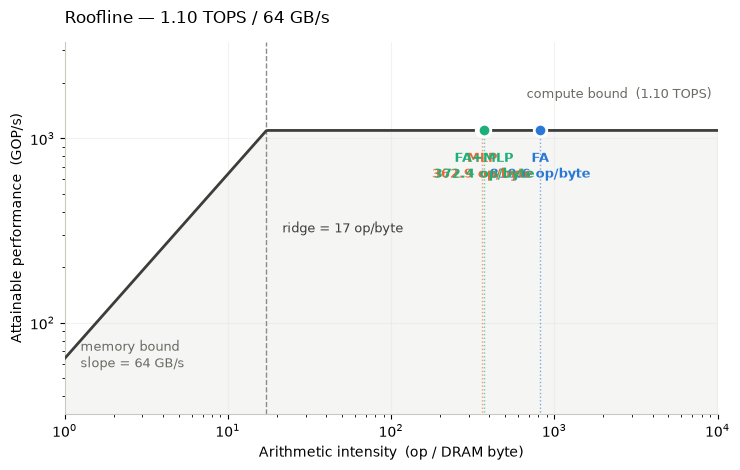

In [2]:
from tile_model import Hardware, data_bytes, divup
from fa import flash_attention
from mlp import mlp
from helper import T, S, H, G, K, D, F, plot_roofline

hw = Hardware()
Mt = 192 # MLP tile
fa = flash_attention(T=T, S=S, H=H, G=G, Br=192, Bc=256, Br_sa1=None, R=256, hw=hw, verbose=False)
ml = mlp(M=T, D=D, F=F, Mt=Mt, Ft=256, Mt_sa1=None, R=256, hw=hw, verbose=False)

# FlashAttention, K groups per layer
fa_ops   = K * 2 * 2 * G * H * T * (T + 1) // 2           # QK^T + PV
fa_bytes = K * (data_bytes((2*S, H), 16) + data_bytes((2*G*T, H), 16))
fa_cyc   = K * fa['cycles']

# MLP: X,
mlp_ops   = 2 * T * 3 * D * F                              # gate, up, down
mlp_bytes = data_bytes((3*T, D), 16) + divup(T, Mt) * data_bytes((3*D, F), 8)
mlp_cyc   = ml['cycles']

peak_ops, peak_mem = 2 * 552, hw.dma_bw                    # op/cycle, byte/cycle
rows = [("FA", fa_ops, fa_bytes, fa_cyc), ("MLP", mlp_ops, mlp_bytes, mlp_cyc),
        ("FA+MLP", fa_ops + mlp_ops, fa_bytes + mlp_bytes, fa_cyc + mlp_cyc)]

print(f"Per layer, one {T}-token sequence (ridge {peak_ops/peak_mem:.1f} op/byte)")
for name, ops, nbytes, cyc in rows:
    print(f"  {name:7s} {ops/1e9:8.1f} Gop  {nbytes/2**20:8.1f} MiB  "
          f"{ops/nbytes:7.1f} op/byte  {ops/cyc:5.0f} op/cycle  {hw.time_us(cyc)/1e3:7.1f} ms")

plot_roofline([(name, round(ops/nbytes, 1)) for name, ops, nbytes, _ in rows], peak_ops, peak_mem)

print()